Create a file geodatabase to store the newly generated feature class files that will be generated later - nanjing analysis.gdb.

Perform the merging of feature classes. Merge into a single feature class file named all_roads.

Perform the fusion operation on all_roads to generate the file all_roads_diss. Each road will retain one line segment as an element.

 Establish spatial links. Target feature is all_roads_diss, connection feature is nanjing_lines_name in basic_roads.gdb, and the output feature class is
all_roads_join.

The fields extracted after the spatial links have been removed are stored in the all_roads_join table, including the
names of urban roads and bus routes.

 Sort and visualize by grouping according to road names.

 Sort the grouped files and export them as CSV files.
Then, connect the fields based on the road names with
the single road feature class file all_roads_diss for spatial
visualization.


# 1.导入相应的库

In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.pyplot import style
style.use('ggplot')
%matplotlib inline

# 2.读取相应数据

In [29]:
# df=pd.read_csv('./TransportData/data_nanjing.csv')
df=pd.read_csv('./amap/data_nj.csv')
df.head()

,,X1路(阅城国际南门--汇康路)
0,,16路(龙福山庄总站--中山码头北)
1,,溧水112路(柘塘--汽车客运站)
2,,135路(油坊桥地铁站--岱山中路南)
3,,197路(尧化门总站--摄山星城总站北)
4,,河西有轨电车1号线(奥体中心东门站--)


In [31]:
# df=pd.read_csv('./TransportData/data_nanjing.csv',names=['roads','lines'])
df=pd.read_csv('./amap/data_nj.csv', names=['roads','lines'])
df.head()

,roads,lines
0,,X1路(阅城国际南门--汇康路)
1,,16路(龙福山庄总站--中山码头北)
2,,溧水112路(柘塘--汽车客运站)
3,,135路(油坊桥地铁站--岱山中路南)
4,,197路(尧化门总站--摄山星城总站北)


In [32]:
df['roads'][0]

' '

In [33]:
len(df['roads'])

8925

In [34]:
df=df[df['roads']!=' ']
len(df['roads'])

8713

In [35]:
df.groupby(by='lines').count()

,roads
lines,
100路(南医大二附院总站--安德门),78
101路(五马渡总站北--仙新路地铁站),140
102路(白龙江西街总站--邺城路·龙王大,18
103路(西春路南--中和村南),16
104路(莫愁新寓--郑和南路),23
...,...
高淳105路(环2路)(高淳枢纽站--高淳枢,96
高淳106路(水产市场--双牌石客运站),82
高淳107路(凤山--淳中路口),102


In [36]:
len(df.groupby(by='roads').count())

1586

In [37]:
dv = df.groupby(by='roads').count().sort_values(by='lines', ascending=False)
dv.head()

,lines
roads,
G42-沪蓉高速公路,52
中山东路,44
软件大道,44
应天大街,41
宁镇公路,37


In [38]:
dv = dv.reset_index()
dv.head()

,roads,lines
0,G42-沪蓉高速公路,52
1,中山东路,44
2,软件大道,44
3,应天大街,41
4,宁镇公路,37


In [39]:
# dv.to_csv('./TransportData/data_nangjing_graphic.csv')
dv.to_csv('./amap/data_nj_gp.csv')

# 3. 城市道路节点度图形可视化

In [40]:
dk = dv.reset_index()
dk.head()

,index,roads,lines
0,0,G42-沪蓉高速公路,52
1,1,中山东路,44
2,2,软件大道,44
3,3,应天大街,41
4,4,宁镇公路,37


In [41]:
dk['index'] = dk['index']+1
dk.head()

,index,roads,lines
0,1,G42-沪蓉高速公路,52
1,2,中山东路,44
2,3,软件大道,44
3,4,应天大街,41
4,5,宁镇公路,37


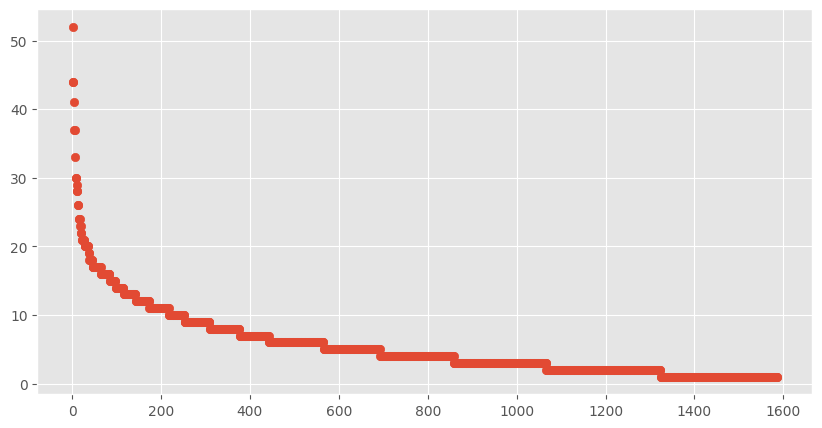

In [18]:
plt.figure(figsize=(10,5))
plt.scatter(dk['index'],dk['lines'])
plt.show()

scipy.org 网站： https://docs.scipy.org/doc/

In [42]:
from scipy import optimize
import scipy.stats

plt.figure(figsize=(10,5))
x = dk['index']
y = dk['lines']

def fm(x,a,b):
    return a*x**b
    
ft1, ft2 = optimize.curve_fit(fm,x,y)
print(ft1)

# plt.scatter(x,y)
# plt.show()

[76.0246861  -0.41952301]


<Figure size 1000x500 with 0 Axes>

In [43]:
### 拟合曲线y值

In [44]:
_y = [y for y in fm(x, ft1[0], ft1[1])]
print(_y)

[76.02468610176088, 56.84151254136139, 47.95029583375931, 42.498794979107565, 38.70086177493705, 35.85108313828986, 33.605979838487656, 31.775149779168075, 30.243214256320105, 28.935542292105904, 27.801385653559674, 26.804843220250962, 25.919687905863093, 25.12624283508735, 24.409410499186226, 23.75738286191207, 23.16077038418683, 22.61199789948073, 22.104875665305386, 21.63428847159338, 21.195966174485932, 20.786311556470007, 20.402269294764558, 20.041224899418964, 19.700925829775873, 19.379419248074544, 19.0750024092599, 18.78618275800851, 18.511645561360424, 18.2502274479578, 18.000894618654552, 17.762724782418026, 17.534892086134395, 17.31665446797359, 17.107342985931883, 16.90635276636547, 16.713135289140347, 16.527191781796624, 16.348067538763065, 16.175347016040128, 16.008649579038988, 15.847625803027261, 15.691954243103691, 15.541338604729454, 15.395505257292216, 15.254201042518101, 15.117191337202234, 14.984258336032536, 14.855199525495715, 14.729826324185224, 14.6079628684426

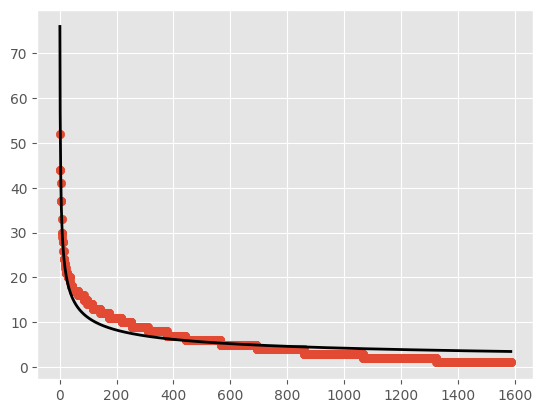

In [45]:
plt.scatter(x,y)
plt.plot(x,_y,color='k',lw=2)
plt.show()

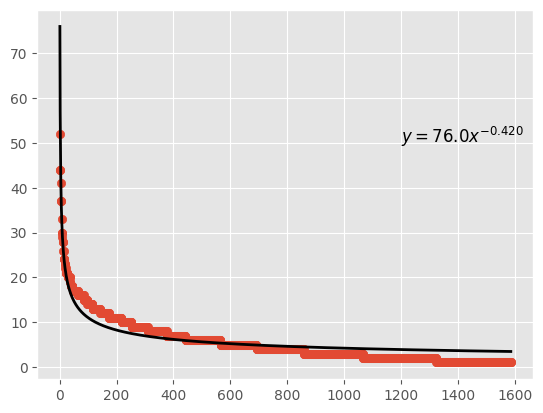

In [46]:
plt.scatter(x,y)
plt.plot(x,_y,color='k',lw=2)
# plt.text(2000,120,'$y={%.1f}x^{%.3f}$' % (ft1[0], ft1[1]), fontsize=12)
# plt.text(1200,50,'${%.1f}x^{%.3f}$'%(ft1[0],ft1[1]),fontsize=12)
plt.text(1200,50,'$y={%.1f}x^{%.3f}$'%(ft1[0],ft1[1]),fontsize=12)
plt.show()

In [47]:
s1,i,r,p,s2 = scipy.stats.linregress(y, _y)
print(r**2)

0.8740490551240898


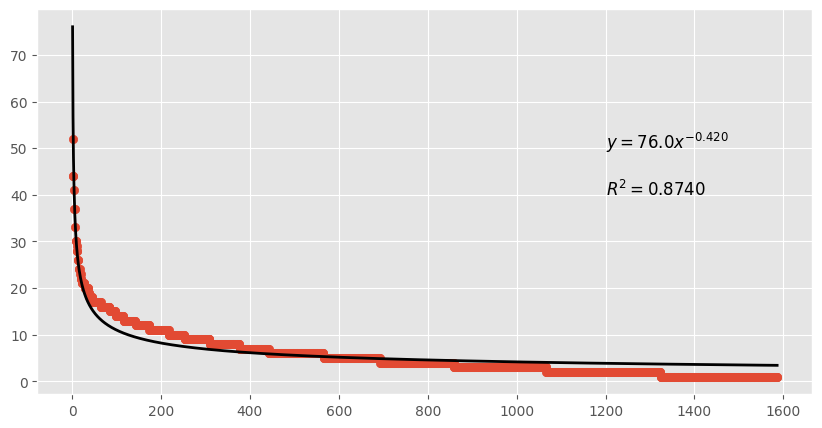

In [48]:
plt.figure(figsize=(10,5))
x=dk['index']
y=dk['lines']

def fm(x,a,b):
    return a*x**b
    
ft1,ft2 = optimize.curve_fit(fm,x,y)
# print(ft1)
_y=[y for y in fm(x,ft1[0],ft1[1])]
s1,i,r,p,s2=scipy.stats.linregress(y,_y)
# print(r**2)
# print(_y)
plt.scatter(x,y)
plt.plot(x,_y,color='k',lw=2)
# plt.text(200,70,'Urban road node degree center order scale distribution', fontsize=12)
# plt.text(2000,120,'$y={%.1f}x^{%.3f}$'%(ft1[0],ft1[1]), fontsize=12)
# plt.text(2000,110,'$R^2={%.4f}$'%(r**2), fontsize=12)
plt.text(1200,50,'$y={%.1f}x^{%.3f}$'%(ft1[0],ft1[1]), fontsize=12)
plt.text(1200,40,'$R^2={%.4f}$'%(r**2), fontsize=12)
plt.show()